## Comparing All years and ACCESS-S2 forecasts for falling below median rainfall anomalies

In [1]:
# Imports
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib import cm, colors
from matplotlib.colors import LinearSegmentedColormap
import sys
sys.path.insert(0,'/home/548/pag548/code/CSIRO_ENSO/config')
sys.path.insert(0,'/home/548/pag548/code/CSIRO_ENSO/src')
import categorical_enso_functions as func
from config import ENS_LIST, CALIBRATED_PR_DIR, YEAR_RANGE, OUT_PATH


In [2]:
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
def format_gridlines(ax, top_labels=False, bottom_labels=False, left_labels=False, right_labels=False):
    
    import cartopy.crs as ccrs
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.75, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = top_labels
    gl.bottom_labels = bottom_labels
    gl.right_labels = right_labels
    gl.left_labels = left_labels
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

In [4]:
# ENSO years
EN = [1963, 1965, 1968, 1969, 1972, 1976, 1977, 1979, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 
      2004, 2006, 2009, 2014, 2015, 2018]

LN = [1964, 1966, 1967, 1970, 1971, 1973, 1974, 1975, 1983, 1984, 1988, 1995, 1996, 1998, 1999, 
      2000, 2005, 2007, 2010, 2011, 2017, 2020, 2021, 2022]

NN = [1960, 1961, 1962, 1978, 1980, 1981, 1985, 1989, 1990, 1992, 1993, 2001, 2003, 2008, 2012, 
      2013, 2016, 2019]

ALL = list(range(1960,2019))

## AGCD

In [5]:
# AGCD landmask
landmask = xr.open_dataset('/g/data/w40/asp561/agcd/mask_australia_0.05deg.nc').landmask

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [6]:
# AGCD data (v2 for precip) 
file_pattern = "/g/data/zv2/agcd/v2-0-2/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_{}.nc"
# Generate list of file paths for years 1960-2022
years = range(1960, 2023)  
paths = [file_pattern.format(year) for year in years]
# Open dataset 
precip = xr.open_mfdataset(paths, combine='nested', concat_dim='time', chunks={'time':12, 'lat':'auto', 'lon':'auto'}).precip

/jobfs/157224811.gadi-pbs/ipykernel_2418164/3338446023.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  precip = xr.open_mfdataset(paths, combine='nested', concat_dim='time', chunks={'time':12, 'lat':'auto', 'lon':'auto'}).precip


In [7]:
# Target all years 
target_years = list(range(1981,2019))

In [8]:
target_years

[1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018]

In [9]:
def spatial_probability_deficit(cdf, anom_data, threshold):
    P = xr.apply_ufunc(
        func.get_probability_deficit, cdf, anom_data, threshold,
        input_core_dims=[["year"], ["year"], []],  # Match time dimension
        output_core_dims=[[]],  # Remove time dim
        vectorize=True,
        dask="parallelized"
    )
    return P

In [10]:
climatologies = []
rainfall_quantiles = []
ALL_probabilities = []
target_anomalies = []


for target_year in target_years:
    
    end_year = target_year - 1
    precip_target = precip.sel(time=f"{target_year}")
    precip_clim = precip.sel(time=slice(None, f"{end_year}-12"))

    clim_son = precip_clim.sel(time=precip_clim.time.dt.season == "SON").groupby("time.year").mean("time").mean("year")
    anom_son = precip_clim.sel(time=precip_clim.time.dt.season == "SON").groupby("time.year").mean("time") - clim_son
    anom_son = anom_son.where(landmask.data == 1)

    anom_son_ALL = anom_son.sel(year=anom_son['year'].isin(ALL)).chunk(chunks={'year': -1, 'lat': -1, 'lon': -1})
    
    q33_rainfall = anom_son.quantile(0.5, dim='year').chunk(chunks={'lat':-1, 'lon':-1})

    sorted_ALL, cdf_ALL = xr.apply_ufunc(
    func.empirical_cdf, 
    anom_son_ALL, 
    input_core_dims=[["year"]],
    output_core_dims=[["year"], ["year"]], 
    vectorize=True,
    dask="parallelized"
    )

    P_ALL_33th = spatial_probability_deficit(cdf_ALL, anom_son_ALL, q33_rainfall)

    anom_target = precip_target.sel(time=precip_target.time.dt.season == "SON").mean("time") - clim_son
    anom_target = anom_target.where(landmask.data == 1)

    climatologies.append(clim_son)
    rainfall_quantiles.append(q33_rainfall)
    ALL_probabilities.append(P_ALL_33th)
    target_anomalies.append(anom_target)

In [11]:
climatologies = xr.concat(climatologies, dim="year").assign_coords(year=target_years)
rainfall_quantiles = xr.concat(rainfall_quantiles, dim="year").assign_coords(year=target_years)
ALL_probabilities = xr.concat(ALL_probabilities, dim="year").assign_coords(year=target_years)
target_anomalies = xr.concat(target_anomalies, dim="year").assign_coords(year=target_years)

## ACCESS-S2

In [12]:
# Function to compute all lead times
LEAD_DICT = {0 : '0901', 
             1 : '0801',
             2 : '0701',
             3 : '0601',
             4 : '0501',
             5 : '0401',
             6 : '0301',
             7 : '0201'}

diff_maps = {}
brier_ALL_results = {}
brier_lead_results = {}

def analyse_access(leadtime):
    """
    Compute ACCESS hindcast anomalies for every target year and then compute Brier Skill Scores
    """

    target_anoms = []
    below_q33 = []

    # Load the hindcast leadtime data from disk
    filename = LEAD_DICT[leadtime]+'.nc'
    ds = xr.load_dataarray( OUT_PATH / filename, chunks={'year' : 38})

    print(f'Loading {OUT_PATH / filename}')
    
    # Convert to mm per month and chunk 
    son_yearly = (ds * 30.33).chunk('auto')

    for target_year in target_years:
        son_target_anom = son_yearly.sel(year=target_year) - climatologies.sel(year=target_year)
        below = (son_target_anom < rainfall_quantiles.sel(year=target_year)).sum(dim="ens") / son_target_anom.ens.size
        target_anoms.append(son_target_anom)
        below_q33.append(below)

        print(f'Computed anomalies for {target_year} for leadtime {leadtime}')
    
    target_anoms_da = xr.concat(target_anoms, dim="year").assign_coords(year=target_years)
    below_q33_da = xr.concat(below_q33, dim="year").assign_coords(year=target_years) 

    brier_ALL_means = []
    brier_lead_means = []
    diff_lead_maps = []

    for year in target_years:
        ALL_prob = ALL_probabilities.sel(year=year).where(landmask.data == 1)
        below_lead = below_q33_da.sel(year=year).where(landmask.data == 1)
        anom_target = target_anomalies.sel(year=year)
        q33_rainfall = rainfall_quantiles.sel(year=year)

        obs_binary = (anom_target < q33_rainfall).astype(int)

        brier_score_ALL = ((ALL_prob - obs_binary) ** 2)
        brier_score_lead = ((below_lead - obs_binary) ** 2)

        #diff_lead_maps.append(brier_score_EN - brier_score_lead)

        brier_ALL_means.append(brier_score_ALL.mean(dim=['lat', 'lon']).values)
        brier_lead_means.append(brier_score_lead.mean(dim=['lat', 'lon']).values)

        print(f'Computed BSS for {year} for leadtime {leadtime}')
    
    #diff_lead_maps = xr.concat(diff_lead_maps, dim="year").assign_coords(year=target_years)
    brier_ALL_means = np.array(brier_ALL_means)
    brier_lead_means = np.array(brier_lead_means)

    #return diff_lead_maps, brier_EN_means, brier_lead_means
    return brier_ALL_means, brier_lead_means

In [13]:
# Compute the rest of the leadtimes
for lead in range(0,8):
    #diff_maps[lead], brier_EN_results[lead], brier_lead_results[lead] =  analyse_access(lead)
    brier_ALL_results[lead], brier_lead_results[lead] =  analyse_access(lead)

Loading /g/data/gb02/pag548/CSIRO_ENSO/0901.nc
Computed anomalies for 1981 for leadtime 0
Computed anomalies for 1982 for leadtime 0
Computed anomalies for 1983 for leadtime 0
Computed anomalies for 1984 for leadtime 0
Computed anomalies for 1985 for leadtime 0
Computed anomalies for 1986 for leadtime 0
Computed anomalies for 1987 for leadtime 0
Computed anomalies for 1988 for leadtime 0
Computed anomalies for 1989 for leadtime 0
Computed anomalies for 1990 for leadtime 0
Computed anomalies for 1991 for leadtime 0
Computed anomalies for 1992 for leadtime 0
Computed anomalies for 1993 for leadtime 0
Computed anomalies for 1994 for leadtime 0
Computed anomalies for 1995 for leadtime 0
Computed anomalies for 1996 for leadtime 0
Computed anomalies for 1997 for leadtime 0
Computed anomalies for 1998 for leadtime 0
Computed anomalies for 1999 for leadtime 0
Computed anomalies for 2000 for leadtime 0
Computed anomalies for 2001 for leadtime 0
Computed anomalies for 2002 for leadtime 0
Compute

In [14]:
cmap = LinearSegmentedColormap.from_list("pink_green", ["#e7298a", "white", "#66a61e"])

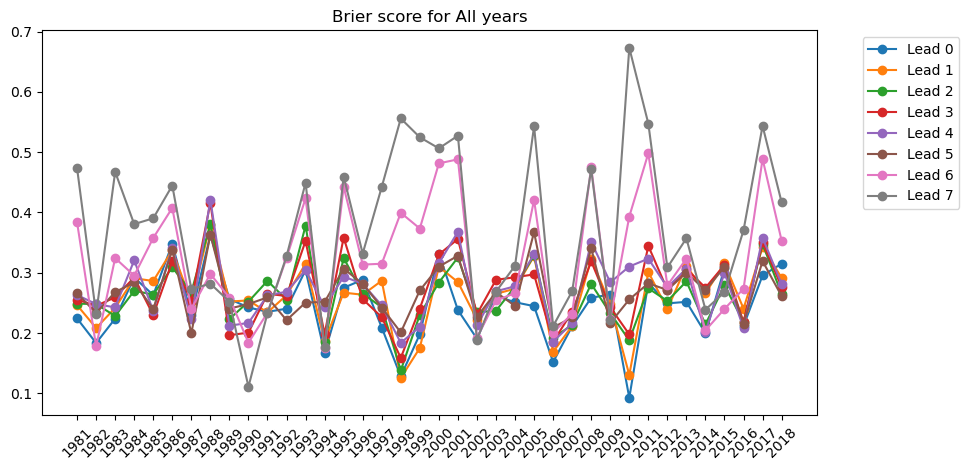

In [23]:
brier_x = np.arange(1,39,1)

plt.figure(figsize=(10, 5))

for lead in range(0,8):
    label = f'Lead {lead}'
    color = cmap(lead/7.0)
    plt.plot(brier_x, brier_lead_results[lead], marker='o', label=label)  # Dark Green

plt.title('Brier score for All years')

plt.xticks(brier_x, target_years,rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

In [18]:
import pandas as pd

In [19]:
df = pd.DataFrame.from_dict(brier_lead_results)

In [20]:
df.to_csv('/home/548/pag548/code/CSIRO_ENSO/Forecasting/ALL_q33_BSS.txt')

In [21]:
df

,0,1,2,3,4,5,6,7
0,0.224120,0.246169,0.248704,0.255401,0.263078,0.265966,0.383647,0.473368
1,0.183318,0.208225,0.247951,0.245086,0.247851,0.233033,0.177881,0.231431
2,0.223871,0.241581,0.228213,0.259181,0.242538,0.267887,0.324231,0.467252
3,0.291991,0.290801,0.269948,0.292073,0.320489,0.283889,0.295187,0.380590
4,0.262914,0.286236,0.263796,0.229793,0.236989,0.239588,0.357606,0.390258
5,0.347829,0.337402,0.308944,0.318803,0.341298,0.338215,0.407507,0.444599
6,0.230071,0.251718,0.267607,0.253636,0.222405,0.199401,0.240157,0.272842
7,0.362376,0.379425,0.380726,0.416127,0.421100,0.363369,0.297995,0.281753
8,0.256318,0.252108,0.223165,0.196373,0.212136,0.240527,0.258409,0.252143
9,0.242349,0.254080,0.251920,0.200590,0.216699,0.247973,0.183837,0.110785
